In [16]:
import numpy as np
house = 10
noise = np.arange(0.1, 1.5, 0.1)
hours = 24
price = 'Realistic'
load_forecast = 0

timings = {}

In [17]:
import torch
import pandas as pd

import src.data.dataprep as prep
import src.data.featurisation as features

from sklearn.metrics import mean_absolute_percentage_error as mape

def torch_py(torch_tensor):
    return torch_tensor.cpu().detach().numpy().flatten()

def rescale(values, scaler):
    rescaled_values = values * (scaler[1] - scaler[0]) + scaler[0]   
    return rescaled_values

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
mapes = []
for n in range(len(noise)):
    # Import the base data and resample it from 5 minutes to hourly
    nl_data = prep.dutch_data('../data/Dutchdata_clean/building_' + str(house) + '.parquet', 'h', price=price)
    featurisation = features.Featurisation(nl_data)
    nl_data = featurisation.cyclic_features(yearly=False)[0]

    load_fcst_data = pd.read_csv('../data/load_fcsts/building_' + str(house) + '_' + str(round(noise[n],1)) + '_noise_forecast.csv', index_col=0)
    nl_data['load_fcst'] = load_fcst_data['load'].values

    mapes.append(mape(nl_data['load'], nl_data['load_fcst']))


In [19]:
import matplotlib.pyplot as plt

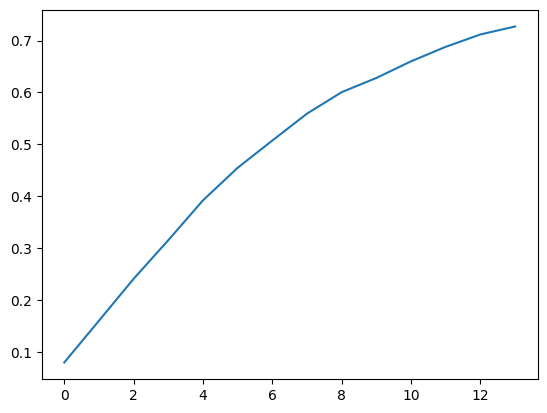

In [20]:
plt.plot(mapes)